1. Завантаження таблиці orders

In [9]:
## імпорт бібліотеки
import pandas as pd

In [8]:
pip install openpyxl

In [14]:
from google.colab import files
uploaded = files.upload()
file_name = next(iter(uploaded))

Saving client_base.xlsx to client_base (3).xlsx


In [15]:
df_orders = pd.read_excel(file_name, sheet_name='orders')
df_orders.head()

,user_id,registration_date,order_date,order_id,purchase_amount,order_channel,payment_method,items_count,delivery_days,order_status
0,U00001,2025-09-19,2025-09-19,ORD-250919-00001,104.81,Email,Debit Card,8,1,Delivered
1,U00001,2025-09-19,2025-10-14,ORD-251014-00002,84.06,Email,Credit Card,1,6,Delivered
2,U00001,2025-09-19,2025-10-16,ORD-251016-00003,63.63,Unknown,Debit Card,1,6,Delivered
3,U00001,2025-09-19,2025-11-23,ORD-251123-00004,112.16,Google Ads,Debit Card,4,5,Delivered
4,U00002,2025-10-20,2025-10-20,ORD-251020-00005,102.52,Google Ads,Credit Card,3,5,Delivered


In [16]:
## базова перевірка (розмір таблиці)
df_orders.shape

(11904, 10)

In [18]:
## базова перевірка (перегляд перших рядків)
df_orders.head()

,user_id,registration_date,order_date,order_id,purchase_amount,order_channel,payment_method,items_count,delivery_days,order_status
0,U00001,2025-09-19,2025-09-19,ORD-250919-00001,104.81,Email,Debit Card,8,1,Delivered
1,U00001,2025-09-19,2025-10-14,ORD-251014-00002,84.06,Email,Credit Card,1,6,Delivered
2,U00001,2025-09-19,2025-10-16,ORD-251016-00003,63.63,Unknown,Debit Card,1,6,Delivered
3,U00001,2025-09-19,2025-11-23,ORD-251123-00004,112.16,Google Ads,Debit Card,4,5,Delivered
4,U00002,2025-10-20,2025-10-20,ORD-251020-00005,102.52,Google Ads,Credit Card,3,5,Delivered


In [19]:
## базова перевірка (типи даних)
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11904 entries, 0 to 11903
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            11904 non-null  object        
 1   registration_date  11904 non-null  datetime64[ns]
 2   order_date         11904 non-null  datetime64[ns]
 3   order_id           11904 non-null  object        
 4   purchase_amount    11904 non-null  float64       
 5   order_channel      11904 non-null  object        
 6   payment_method     11904 non-null  object        
 7   items_count        11904 non-null  int64         
 8   delivery_days      11904 non-null  int64         
 9   order_status       11904 non-null  object        
dtypes: datetime64[ns](2), float64(1), int64(2), object(5)
memory usage: 930.1+ KB


In [20]:
## базова перевірка (наявність пропусків)
df_orders.isna().sum()

,0
user_id,0
registration_date,0
order_date,0
order_id,0
purchase_amount,0
order_channel,0
payment_method,0
items_count,0
delivery_days,0
order_status,0


2. Створення колонок для когортного аналізу

In [21]:
## створення cohort_month
df_orders["cohort_month"] = df_orders["registration_date"].dt.to_period("M").astype(str)
df_orders.head(3)

,user_id,registration_date,order_date,order_id,purchase_amount,order_channel,payment_method,items_count,delivery_days,order_status,cohort_month
0,U00001,2025-09-19,2025-09-19,ORD-250919-00001,104.81,Email,Debit Card,8,1,Delivered,2025-09
1,U00001,2025-09-19,2025-10-14,ORD-251014-00002,84.06,Email,Credit Card,1,6,Delivered,2025-09
2,U00001,2025-09-19,2025-10-16,ORD-251016-00003,63.63,Unknown,Debit Card,1,6,Delivered,2025-09


In [22]:
## створення order_month
df_orders["order_month"] = df_orders["order_date"].dt.to_period("M").astype(str)
df_orders.head(3)

,user_id,registration_date,order_date,order_id,purchase_amount,order_channel,payment_method,items_count,delivery_days,order_status,cohort_month,order_month
0,U00001,2025-09-19,2025-09-19,ORD-250919-00001,104.81,Email,Debit Card,8,1,Delivered,2025-09,2025-09
1,U00001,2025-09-19,2025-10-14,ORD-251014-00002,84.06,Email,Credit Card,1,6,Delivered,2025-09,2025-10
2,U00001,2025-09-19,2025-10-16,ORD-251016-00003,63.63,Unknown,Debit Card,1,6,Delivered,2025-09,2025-10


In [23]:
## створення month_elapsed
df_orders["month_elapsed"] = (
(df_orders["order_date"].dt.year - df_orders["registration_date"].dt.year) * 12
+ (df_orders["order_date"].dt.month - df_orders["registration_date"].dt.month)
)
df_orders.head(3)

,user_id,registration_date,order_date,order_id,purchase_amount,order_channel,payment_method,items_count,delivery_days,order_status,cohort_month,order_month,month_elapsed
0,U00001,2025-09-19,2025-09-19,ORD-250919-00001,104.81,Email,Debit Card,8,1,Delivered,2025-09,2025-09,0
1,U00001,2025-09-19,2025-10-14,ORD-251014-00002,84.06,Email,Credit Card,1,6,Delivered,2025-09,2025-10,1
2,U00001,2025-09-19,2025-10-16,ORD-251016-00003,63.63,Unknown,Debit Card,1,6,Delivered,2025-09,2025-10,1


3. Побудова графіків

In [24]:
##графік cohort_size
acq_counts = (df_orders.groupby("cohort_month")["user_id"].nunique().reset_index(name="users"))
acq_counts["cohort_month_dt"] = pd.to_datetime(acq_counts["cohort_month"])
acq_counts = acq_counts.sort_values("cohort_month_dt")
acq_counts

,cohort_month,users,cohort_month_dt
0,2025-01,317,2025-01-01
1,2025-02,291,2025-02-01
2,2025-03,215,2025-03-01
3,2025-04,206,2025-04-01
4,2025-05,221,2025-05-01
5,2025-06,178,2025-06-01
6,2025-07,452,2025-07-01
7,2025-08,317,2025-08-01
8,2025-09,228,2025-09-01
9,2025-10,208,2025-10-01


In [28]:
## імпорт бібліотек для побудови графіків
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

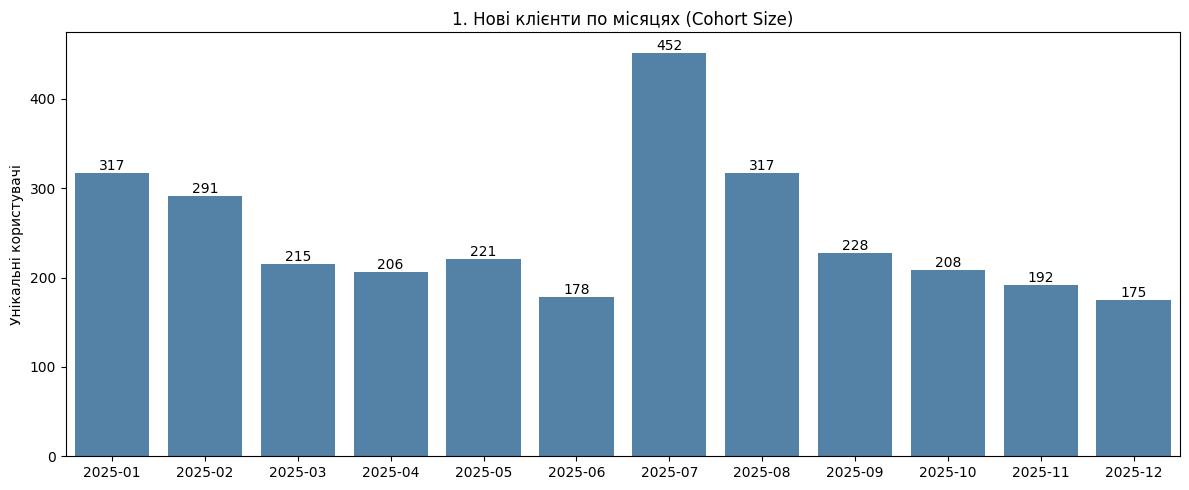

In [31]:
plt.figure(figsize=(12, 5))
ax = sns.barplot(data=acq_counts, color="steelblue"
, x="cohort_month"
, y="users")
plt.title("1. Нові клієнти по місяцях (Cohort Size)")
plt.ylabel("Унікальні користувачі"
)
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
f"{height:.0f}",
(p.get_x() + p.get_width() / 2, height)
,
ha="center", va="bottom"
)
plt.xlabel("")
plt.tight_layout()
plt.show()

In [43]:
## графік revenue_&_orders
monthly = (df_orders.groupby("order_month").agg(
orders=("order_id"
,
"count"),
revenue=("purchase_amount"
,
"sum")).reset_index()
)
monthly = monthly.sort_values("order_month")
monthly

,order_month,orders,revenue
0,2025-01,554,71546.12
1,2025-02,701,95787.41
2,2025-03,858,114871.56
3,2025-04,899,116906.88
4,2025-05,953,126211.02
5,2025-06,912,119791.15
6,2025-07,1299,176556.40
7,2025-08,1409,179603.16
8,2025-09,1128,150446.59
9,2025-10,1236,161706.69


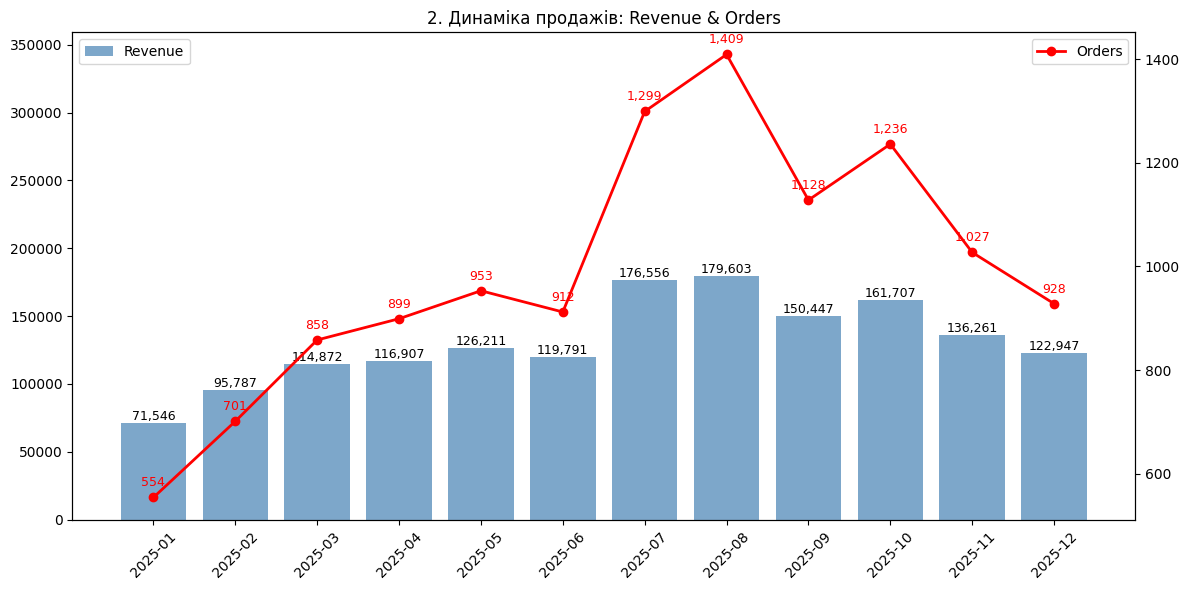

In [67]:
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.bar(monthly["order_month"], monthly["revenue"], color="steelblue"
, alpha=0.7, label="Revenue")
ax1.set_ylim(0, monthly["revenue"].max() * 2)
ax1.tick_params(axis="x"
, rotation=45)
for bar in ax1.patches:
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f"{bar.get_height():,.0f}"
             , ha="center"
             , va="bottom"
             , fontsize=9)
ax2 = ax1.twinx()
ax2.plot(monthly["order_month"], monthly["orders"], color="red"
, marker="o"
, linewidth=2,
label="Orders")
for x, y in zip(monthly['order_month'], monthly['orders']):
  ax2.annotate(
      f"{y:,.0f}",
      (x,y),
      textcoords="offset points",
      xytext=(0,8),
      ha="center",
      fontsize=9,
      color="red"
      )
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.title("2. Динаміка продажів: Revenue & Orders")
plt.tight_layout()
plt.show()

In [48]:
## побудова retention_count
retention_counts = (
df_orders
.groupby(["cohort_month"
,
"month_elapsed"])["user_id"]
.nunique()
.reset_index(name="users")
)
retention_counts

,cohort_month,month_elapsed,users
0,2025-01,0,317
1,2025-01,1,160
2,2025-01,2,137
3,2025-01,3,119
4,2025-01,4,75
...,...,...,...
72,2025-10,1,113
73,2025-10,2,94
74,2025-11,0,192
75,2025-11,1,95


In [47]:
retention_pivot = retention_counts.pivot_table(index="cohort_month"
, columns="month_elapsed"
, values="users")
retention_pivot

month_elapsed,0,1,2,3,4,5,6,7,8,9,10
cohort_month,,,,,,,,,,,
2025-01,317.0,160.0,137.0,119.0,75.0,52.0,27.0,18.0,6.0,4.0,1.0
2025-02,291.0,170.0,120.0,100.0,72.0,38.0,26.0,14.0,6.0,5.0,2.0
2025-03,215.0,112.0,96.0,66.0,40.0,24.0,18.0,9.0,5.0,3.0,NaN
2025-04,206.0,119.0,96.0,77.0,55.0,26.0,17.0,7.0,3.0,NaN,NaN
2025-05,221.0,122.0,97.0,74.0,48.0,29.0,25.0,13.0,NaN,NaN,NaN
2025-06,178.0,95.0,87.0,54.0,42.0,27.0,16.0,NaN,NaN,NaN,NaN
2025-07,452.0,248.0,178.0,174.0,113.0,59.0,NaN,NaN,NaN,NaN,NaN
2025-08,317.0,155.0,151.0,99.0,75.0,NaN,NaN,NaN,NaN,NaN,NaN
2025-09,228.0,138.0,98.0,73.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


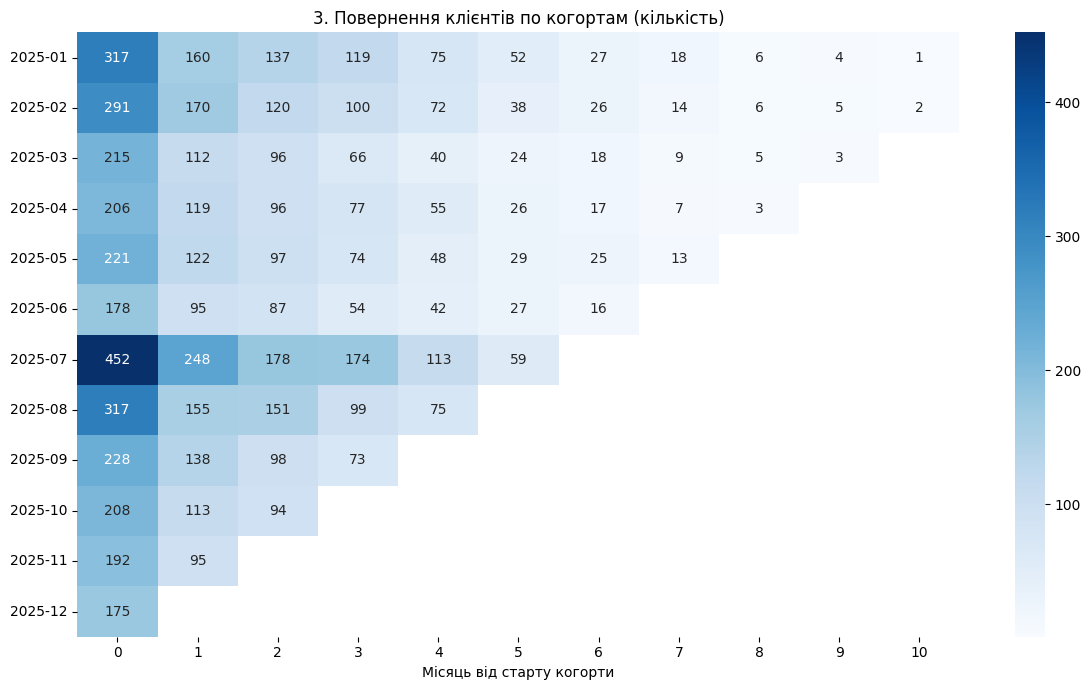

In [51]:
## теплокарта retention_count
plt.figure(figsize=(12, 7))
sns.heatmap(retention_pivot, annot=True, fmt="g"
, cmap="Blues")
plt.title("3. Повернення клієнтів по когортам (кількість)")
plt.xlabel("Місяць від старту когорти")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [52]:
## побудова retention_rate
cohort_size = (df_orders[df_orders["month_elapsed"] == 0].groupby("cohort_month")["user_id"].nunique() )
cohort_size

,user_id
cohort_month,
2025-01,317
2025-02,291
2025-03,215
2025-04,206
2025-05,221
2025-06,178
2025-07,452
2025-08,317
2025-09,228


In [53]:
retention_pct = retention_pivot.div(cohort_size, axis=0) * 100
retention_pct

month_elapsed,0,1,2,3,4,5,6,7,8,9,10
cohort_month,,,,,,,,,,,
2025-01,100.0,50.473186,43.217666,37.539432,23.659306,16.403785,8.517350,5.678233,1.892744,1.261830,0.315457
2025-02,100.0,58.419244,41.237113,34.364261,24.742268,13.058419,8.934708,4.810997,2.061856,1.718213,0.687285
2025-03,100.0,52.093023,44.651163,30.697674,18.604651,11.162791,8.372093,4.186047,2.325581,1.395349,NaN
2025-04,100.0,57.766990,46.601942,37.378641,26.699029,12.621359,8.252427,3.398058,1.456311,NaN,NaN
2025-05,100.0,55.203620,43.891403,33.484163,21.719457,13.122172,11.312217,5.882353,NaN,NaN,NaN
2025-06,100.0,53.370787,48.876404,30.337079,23.595506,15.168539,8.988764,NaN,NaN,NaN,NaN
2025-07,100.0,54.867257,39.380531,38.495575,25.000000,13.053097,NaN,NaN,NaN,NaN,NaN
2025-08,100.0,48.895899,47.634069,31.230284,23.659306,NaN,NaN,NaN,NaN,NaN,NaN
2025-09,100.0,60.526316,42.982456,32.017544,NaN,NaN,NaN,NaN,NaN,NaN,NaN


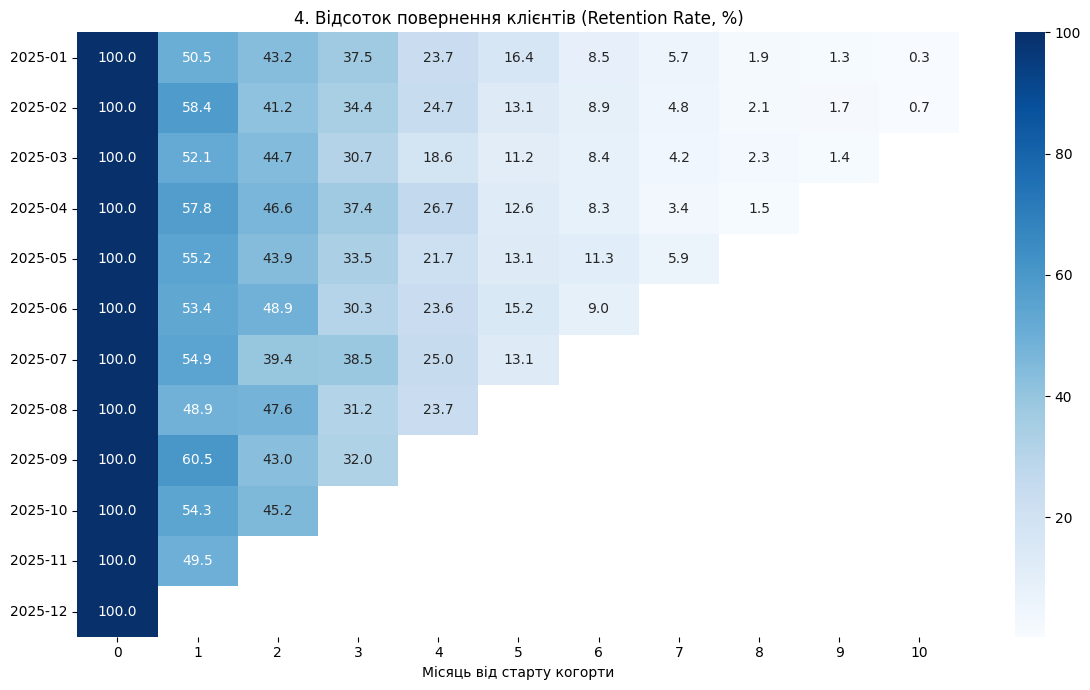

In [66]:
## теплокарта retantion_rate
plt.figure(figsize=(12, 7))
sns.heatmap(retention_pct, annot=True, fmt=".1f", cmap="Blues")
plt.title("4. Відсоток повернення клієнтів (Retention Rate, %)")
plt.xlabel("Місяць від старту когорти")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [64]:
## графік каналів залучення
acq_counts = (df_orders.groupby("order_channel")["user_id"].nunique().reset_index(name="users"))
acq_counts

,order_channel,users
0,Email,1354
1,Facebook,1601
2,Google Ads,1596
3,Instagram,1747
4,Referral,1353
5,Unknown,986


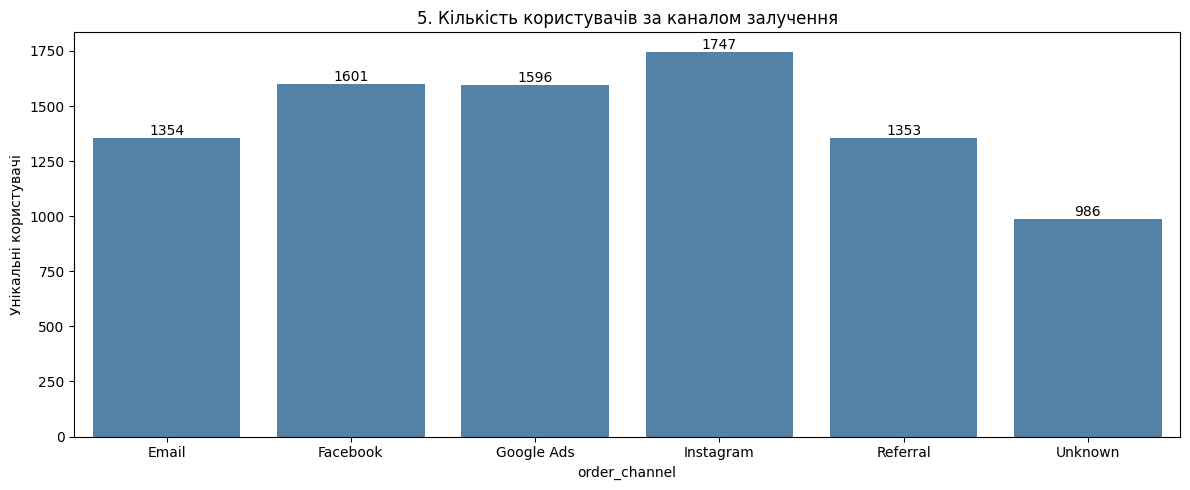

In [65]:
plt.figure(figsize=(12, 5))
ax = sns.barplot(data=acq_counts, color="steelblue"
, x="order_channel"
, y="users")
plt.title("5. Кількість користувачів за каналом залучення")
plt.ylabel("")
plt.ylabel("Унікальні користувачі")
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height:.0f}",
        (p.get_x() + p.get_width() / 2, height),
        ha="center", va="bottom"
)
plt.tight_layout()
plt.show()